# Ultimate Game Insights：初始数据探索

## 0. 项目背景

本项目使用 Kaggle 上的 Ultimate Games Dataset，对游戏数据进行基础探索分析。数据集中包含游戏名称、发行时间、游戏类型、平台、评分、游玩时长、热度、参与度等字段，适合用于课程中的表格数据分析和可视化练习。

数据集来源：https://www.kaggle.com/datasets/rudrakumargupta/ultimate-games-dataset-15k-games-43-features/data

当前 Notebook 是项目的最初版本，主要完成数据读取、数据概览、数据质量检查、基础预处理、简单特征工程和初步可视化。这个阶段不训练模型，不做推荐系统，也不做复杂预测任务，重点是先把数据理解清楚，并保证代码可以运行、结果可以验证。

## 1. 环境检查

在正式分析数据之前，先检查当前 Python 版本、常用依赖包版本和工作目录。这样做的目的是保证分析过程更容易复现，也方便之后排查环境问题。

In [1]:
import os
import sys
from pathlib import Path
from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Ultimate_Games_Dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Python version:", sys.version.replace("\n", " "))
print("Current working directory:", current_dir)
print("Project root:", PROJECT_ROOT)

versions = pd.DataFrame({
    "package": ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"],
    "version": [pd.__version__, np.__version__, matplotlib.__version__, sns.__version__, sklearn.__version__],
})
display(versions)

Python version: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
Current working directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/notebooks
Project root: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights


,package,version
0,pandas,3.0.3
1,numpy,2.4.4
2,matplotlib,3.10.9
3,seaborn,0.13.2
4,scikit-learn,1.8.0


运行结果中应该能看到 Python 版本、`pandas`、`numpy`、`matplotlib`、`seaborn`、`scikit-learn` 等包的版本，以及当前 Notebook 的运行目录。如果换到另一台电脑运行，优先检查这里的环境信息是否一致。

## 2. 读取数据集

本项目约定把原始数据文件放在 `data/raw/Ultimate_Games_Dataset.csv`。下面的代码会读取这个 CSV 文件，并展示前 5 行数据和数据集的行列规模。

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset file not found. Please place the CSV file at: "
        f"{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

display(df.head())
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

,serial_no,game_id,title,release_date,release_year,all_genres,theme,art_style,view_dimension,game_mode,...,cover_image_url,official_website,url_slug,description_clean,popularity_score,engagement_score,decade,is_multi_platform,rating_tier,metacritic_tier
0,1,3498,Grand Theft Auto V,2013-09-17,2013.0,Action,Crime,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/20a/20aa03a1...,http://www.rockstargames.com/V/,grand-theft-auto-v,"Rockstar Games went bigger, since their previo...",96.28,21.75,2010s,1,excellent,universal_acclaim
1,2,3328,The Witcher 3: Wild Hunt,2015-05-18,2015.0,Action|RPG,Fantasy,Realistic,3D,Singleplayer,...,https://media.rawg.io/media/games/618/618c2031...,https://thewitcher.com/en/witcher3,the-witcher-3-wild-hunt,"The third game in a series, it holds nothing b...",95.81,17.19,2010s,1,masterpiece,universal_acclaim
2,3,4200,Portal 2,2011-04-18,2011.0,Shooter|Puzzle,Sci-Fi,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/2ba/2bac0e87...,http://www.thinkwithportals.com/,portal-2,Portal 2 is a first-person puzzle game develop...,91.26,15.24,2010s,1,masterpiece,universal_acclaim
3,4,4291,Counter-Strike: Global Offensive,2012-08-21,2012.0,Shooter,Horror,Realistic,3D,Multiplayer,...,https://media.rawg.io/media/games/736/73619bd3...,http://blog.counter-strike.net/,counter-strike-global-offensive,Counter-Strike is a multiplayer phenomenon in ...,73.56,8.79,2010s,1,good,generally_favorable
4,5,5286,Tomb Raider (2013),2013-03-05,2013.0,Action,Adventure,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/021/021c4e21...,http://www.tombraider.com,tomb-raider,A cinematic revival of the series in its actio...,76.54,13.77,2010s,1,excellent,generally_favorable


Dataset shape: 15,000 rows x 43 columns


读取完成后，需要确认数据规模是否符合预期，并简单查看前几行内容。这里重点观察游戏标题、发行日期、游戏类型、游戏平台、评分、热度和参与度等字段是否正常读取。

## 3. 数据基本概览

这一部分用于了解表格数据的基本结构，包括字段名、字段类型、缺失值情况，以及哪些字段可能属于数值型、类别型、时间型和文本型字段。这一步对应课程中“表格数据分析”的基础思路。

In [3]:
print("DataFrame info:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_ratio": (df.isna().mean() * 100).round(2).values,
})

display(column_summary)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
possible_time_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in ["date", "year", "decade", "time"])
]
possible_text_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in ["title", "name", "description", "slug", "url", "website"])
]

print("Numeric columns:")
pprint(numeric_cols)
print("\nCategorical columns:")
pprint(categorical_cols)
print("\nPossible time columns:")
pprint(possible_time_cols)
print("\nPossible text columns:")
pprint(possible_text_cols)

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   serial_no           15000 non-null  int64  
 1   game_id             15000 non-null  int64  
 2   title               15000 non-null  str    
 3   release_date        15000 non-null  str    
 4   release_year        15000 non-null  float64
 5   all_genres          15000 non-null  str    
 6   theme               15000 non-null  str    
 7   art_style           15000 non-null  str    
 8   view_dimension      15000 non-null  str    
 9   game_mode           15000 non-null  str    
 10  is_multiplayer      15000 non-null  int64  
 11  controls            15000 non-null  str    
 12  developers          15000 non-null  str    
 13  publishers          15000 non-null  str    
 14  all_platforms       15000 non-null  str    
 15  platform_count      15000 non-null  float64
 16 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
serial_no,15000.0,NaN,NaN,NaN,7500.5,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
game_id,15000.0,NaN,NaN,NaN,249763.827,342132.093404,2.0,14743.25,28871.0,484814.5,1006908.0
title,15000,15000,Grand Theft Auto V,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,15000,5439,2016-04-05,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,15000.0,NaN,NaN,NaN,2015.643267,6.514203,1979.0,2014.0,2016.0,2020.0,2026.0
all_genres,15000,923,Adventure|Indie,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
theme,15000,12,Sci-Fi,3160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
art_style,15000,7,Realistic,5557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
view_dimension,15000,4,3D,7550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
game_mode,15000,4,Singleplayer,9283,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,column,dtype,missing_count,missing_ratio
0,serial_no,int64,0,0.00
1,game_id,int64,0,0.00
2,title,str,0,0.00
3,release_date,str,0,0.00
4,release_year,float64,0,0.00
5,all_genres,str,0,0.00
6,theme,str,0,0.00
7,art_style,str,0,0.00
8,view_dimension,str,0,0.00
9,game_mode,str,0,0.00


Numeric columns:
['serial_no',
 'game_id',
 'release_year',
 'is_multiplayer',
 'platform_count',
 'user_rating',
 'metacritic',
 'ratings_count',
 'reviews_count',
 'library_count',
 'avg_playtime_hours',
 'achievements_count',
 'game_series_count',
 'status_owned',
 'status_beaten',
 'status_playing',
 'status_dropped',
 'status_toplay',
 'status_yet',
 'popularity_score',
 'engagement_score',
 'is_multi_platform']

Categorical columns:
['title',
 'release_date',
 'all_genres',
 'theme',
 'art_style',
 'view_dimension',
 'game_mode',
 'controls',
 'developers',
 'publishers',
 'all_platforms',
 'esrb_rating',
 'all_tags',
 'available_stores',
 'cover_image_url',
 'official_website',
 'url_slug',
 'description_clean',
 'decade',
 'rating_tier',
 'metacritic_tier']

Possible time columns:
['release_date', 'release_year', 'avg_playtime_hours', 'decade']

Possible text columns:
['title',
 'cover_image_url',
 'official_website',
 'url_slug',
 'description_clean']


/var/folders/yl/dc74thx936v5t2s24kmtx53m0000gn/T/ipykernel_63222/3046356467.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


字段概览可以帮助我们判断哪些列需要类型转换、哪些列存在缺失值、哪些列适合后续做统计分析或可视化。当前阶段只做观察和总结，不随意删除数据。

## 4. 缺失值、重复值和基础数据质量检查

参考课程 PPT 中的数据清洗思路，这一部分检查每列缺失值、重复行数量，以及关键数值字段是否存在明显异常范围。这里的目标是先发现问题，而不是马上修改或删除数据。

In [4]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio": (df.isna().mean() * 100).round(2),
    })
    .query("missing_count > 0")
    .sort_values("missing_ratio", ascending=False)
)

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count:,}")

key_numeric_fields = [
    "user_rating",
    "metacritic",
    "avg_playtime_hours",
    "popularity_score",
    "engagement_score",
]
existing_key_numeric_fields = [col for col in key_numeric_fields if col in df.columns]

range_stats = pd.DataFrame()
if existing_key_numeric_fields:
    numeric_check = df[existing_key_numeric_fields].apply(pd.to_numeric, errors="coerce")
    range_stats = numeric_check.agg(["count", "min", "max", "mean", "median"]).T.round(2)

quality_records = []
quality_records.append({
    "check_type": "duplicate_rows",
    "column": "all_columns",
    "issue": "Duplicated full rows",
    "affected_rows": duplicate_count,
})

for col, row in missing_summary.iterrows():
    quality_records.append({
        "check_type": "missing_values",
        "column": col,
        "issue": f"Missing ratio: {row['missing_ratio']}%",
        "affected_rows": int(row["missing_count"]),
    })

expected_ranges = {
    "user_rating": (0, 10),
    "metacritic": (0, 100),
    "avg_playtime_hours": (0, None),
    "popularity_score": (0, None),
    "engagement_score": (0, None),
}

for col, (lower, upper) in expected_ranges.items():
    if col not in df.columns:
        continue
    values = pd.to_numeric(df[col], errors="coerce")
    mask = pd.Series(False, index=df.index)
    if lower is not None:
        mask = mask | (values < lower)
    if upper is not None:
        mask = mask | (values > upper)
    affected = int(mask.sum())
    if affected > 0:
        quality_records.append({
            "check_type": "range_check",
            "column": col,
            "issue": f"Values outside expected range {lower} to {upper}",
            "affected_rows": affected,
        })

quality_issues = pd.DataFrame(quality_records).sort_values("affected_rows", ascending=False)

print("Missing value summary:")
display(missing_summary)
print("Key numeric field ranges:")
display(range_stats)
print("Data quality issue table:")
display(quality_issues)

Duplicate rows: 0
Missing value summary:


,missing_count,missing_ratio
metacritic,886,5.91
user_rating,387,2.58


Key numeric field ranges:


,count,min,max,mean,median
user_rating,14613.0,1.00,5.00,3.27,3.43
metacritic,14114.0,23.00,99.00,70.72,70.00
avg_playtime_hours,15000.0,0.00,367.00,3.72,3.00
popularity_score,15000.0,1.61,96.28,24.93,26.50
engagement_score,15000.0,0.00,41.93,3.81,1.83


Data quality issue table:


,check_type,column,issue,affected_rows
1,missing_values,metacritic,Missing ratio: 5.91%,886
2,missing_values,user_rating,Missing ratio: 2.58%,387
0,duplicate_rows,all_columns,Duplicated full rows,0


这一步采取比较保守的处理方式：只统计并展示缺失值、重复值和可能的异常范围，不直接删除行或修改原始数据。后续是否清洗，需要结合分析目标再决定。

## 5. 基础预处理

这一部分进行温和的数据预处理，主要是为了让后续分析更方便，同时尽量保留原始信息。具体包括：转换发行日期、确认发行年份、检查应为数值的字段，以及把多标签字段拆分成列表形式的辅助列。

In [5]:
df_processed = df.copy()

if "release_date" in df_processed.columns:
    df_processed["release_date_parsed"] = pd.to_datetime(df_processed["release_date"], errors="coerce")
else:
    df_processed["release_date_parsed"] = pd.NaT

if "release_year" in df_processed.columns:
    df_processed["release_year_num"] = pd.to_numeric(df_processed["release_year"], errors="coerce").astype("Int64")
else:
    df_processed["release_year_num"] = df_processed["release_date_parsed"].dt.year.astype("Int64")

if "release_date_parsed" in df_processed.columns:
    df_processed["release_year_from_date"] = df_processed["release_date_parsed"].dt.year.astype("Int64")
    year_compare_mask = (
        df_processed["release_year_num"].notna()
        & df_processed["release_year_from_date"].notna()
        & (df_processed["release_year_num"] != df_processed["release_year_from_date"])
    )
    print(f"Rows where release_year differs from release_date year: {int(year_compare_mask.sum()):,}")

numeric_candidates = [
    "user_rating", "metacritic", "ratings_count", "reviews_count", "library_count",
    "avg_playtime_hours", "achievements_count", "game_series_count", "platform_count",
    "popularity_score", "engagement_score", "is_multiplayer", "is_multi_platform",
]

created_numeric_columns = []
for col in numeric_candidates:
    if col in df_processed.columns and not pd.api.types.is_numeric_dtype(df_processed[col]):
        new_col = f"{col}_num"
        df_processed[new_col] = pd.to_numeric(df_processed[col], errors="coerce")
        created_numeric_columns.append(new_col)

print("New numeric helper columns created:")
pprint(created_numeric_columns)


def split_multi_label(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    for separator in ["|", ";", ","]:
        if separator in text:
            return [item.strip() for item in text.split(separator) if item.strip()]
    return [text]

multi_label_columns = ["all_genres", "all_platforms", "all_tags", "developers", "publishers", "available_stores"]
created_list_columns = []
for col in multi_label_columns:
    if col in df_processed.columns:
        list_col = f"{col}_list"
        df_processed[list_col] = df_processed[col].apply(split_multi_label)
        created_list_columns.append(list_col)

print("New multi-label helper columns created:")
pprint(created_list_columns)

display(df_processed[[col for col in ["title", "release_date", "release_year", "release_date_parsed", "release_year_num", "all_genres_list", "all_platforms_list", "all_tags_list"] if col in df_processed.columns]].head())

Rows where release_year differs from release_date year: 0
New numeric helper columns created:
[]
New multi-label helper columns created:
['all_genres_list',
 'all_platforms_list',
 'all_tags_list',
 'developers_list',
 'publishers_list',
 'available_stores_list']


,title,release_date,release_year,release_date_parsed,release_year_num,all_genres_list,all_platforms_list,all_tags_list
0,Grand Theft Auto V,2013-09-17,2013.0,2013-09-17,2013,[Action],"[PC, PlayStation 5, Xbox Series S/X, PlayStati...","[Singleplayer, Steam Achievements, Multiplayer..."
1,The Witcher 3: Wild Hunt,2015-05-18,2015.0,2015-05-18,2015,"[Action, RPG]","[Xbox Series S/X, PlayStation 5, macOS, PlaySt...","[Singleplayer, Full controller support, Atmosp..."
2,Portal 2,2011-04-18,2011.0,2011-04-18,2011,"[Shooter, Puzzle]","[PlayStation 3, PC, Xbox 360, Linux, macOS, Xb...","[Singleplayer, Steam Achievements, Multiplayer..."
3,Counter-Strike: Global Offensive,2012-08-21,2012.0,2012-08-21,2012,[Shooter],"[PC, Linux, Xbox 360, PlayStation 3]","[Steam Achievements, Multiplayer, Full control..."
4,Tomb Raider (2013),2013-03-05,2013.0,2013-03-05,2013,[Action],"[PlayStation 3, Xbox 360, macOS, PC, Xbox One,...","[Singleplayer, Multiplayer, Full controller su..."


这些辅助列不会覆盖原始字段，因此仍然可以回到原始数据进行检查。这样做的好处是 Notebook 的处理过程比较透明，也方便之后尝试不同的数据处理方式。

## 6. 基础特征工程

特征工程的目标是从原始字段中构造更容易分析的新变量。这里构造的都是描述性特征，例如类型数量、平台数量、标签数量、描述文本长度、发行年代和是否为近年游戏。当前版本不做机器学习编码，也不构建复杂模型。

In [6]:
df_features = df_processed.copy()

if "all_genres_list" in df_features.columns:
    df_features["genre_count"] = df_features["all_genres_list"].apply(len)
else:
    df_features["genre_count"] = np.nan

if "all_platforms_list" in df_features.columns:
    df_features["platform_count_check"] = df_features["all_platforms_list"].apply(len)
else:
    df_features["platform_count_check"] = np.nan

if "all_tags_list" in df_features.columns:
    df_features["tag_count"] = df_features["all_tags_list"].apply(len)
else:
    df_features["tag_count"] = np.nan

if "description_clean" in df_features.columns:
    df_features["description_length"] = df_features["description_clean"].fillna("").astype(str).str.len()
else:
    df_features["description_length"] = np.nan


def make_decade(year):
    if pd.isna(year):
        return pd.NA
    year = int(year)
    return f"{(year // 10) * 10}s"

if "release_year_num" in df_features.columns:
    df_features["release_decade"] = df_features["release_year_num"].apply(make_decade)
    df_features["is_recent_game"] = np.where(
        df_features["release_year_num"].notna(),
        df_features["release_year_num"] >= 2020,
        pd.NA,
    )
else:
    df_features["release_decade"] = pd.NA
    df_features["is_recent_game"] = pd.NA

feature_cols = [
    "title", "release_year_num", "release_decade", "is_recent_game",
    "genre_count", "platform_count_check", "tag_count", "description_length",
]
feature_cols = [col for col in feature_cols if col in df_features.columns]

display(df_features[feature_cols].head())

display(df_features[["genre_count", "platform_count_check", "tag_count", "description_length"]].describe().T.round(2))

if {"platform_count", "platform_count_check"}.issubset(df_features.columns):
    platform_compare = df_features[["platform_count", "platform_count_check"]].copy()
    platform_compare["platform_count"] = pd.to_numeric(platform_compare["platform_count"], errors="coerce")
    platform_compare["difference"] = platform_compare["platform_count"] - platform_compare["platform_count_check"]
    print("Platform count comparison:")
    display(platform_compare["difference"].value_counts(dropna=False).head(10).rename_axis("difference").reset_index(name="rows"))

,title,release_year_num,release_decade,is_recent_game,genre_count,platform_count_check,tag_count,description_length
0,Grand Theft Auto V,2013,2010s,False,1,7,19,1012
1,The Witcher 3: Wild Hunt,2015,2010s,False,2,7,20,980
2,Portal 2,2011,2010s,False,2,6,25,1940
3,Counter-Strike: Global Offensive,2012,2010s,False,1,4,24,1233
4,Tomb Raider (2013),2013,2010s,False,1,6,17,1264


,count,mean,std,min,25%,50%,75%,max
genre_count,15000.0,2.55,1.23,1.0,2.0,2.0,3.00,19.0
platform_count_check,15000.0,2.60,1.87,1.0,1.0,2.0,3.00,22.0
tag_count,15000.0,11.87,8.05,1.0,5.0,11.0,19.00,66.0
description_length,15000.0,1346.90,1015.19,51.0,764.0,1153.0,1643.25,47827.0


Platform count comparison:


,difference,rows
0,0.0,15000


这些新特征可以帮助我们从更直观的角度理解游戏数据，例如一款游戏覆盖多少类型、是否跨平台发行、描述文本是否较长，以及游戏主要集中在哪些发行年代。

## 7. 初步可视化分析

下面通过图表把表格中的复杂信息转化为更容易理解的趋势和分布。每张图都会保存为 PNG 文件到 `figures/` 目录。图表标题和坐标轴使用英文，是为了避免不同电脑上中文字体显示异常。

In [7]:
def save_current_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {output_path}")


def numeric_series(data, column):
    if column not in data.columns:
        return pd.Series(dtype="float64")
    return pd.to_numeric(data[column], errors="coerce")


def skip_plot(reason):
    print(f"Skipped plot: {reason}")

### 7.1 不同发行年代的游戏数量

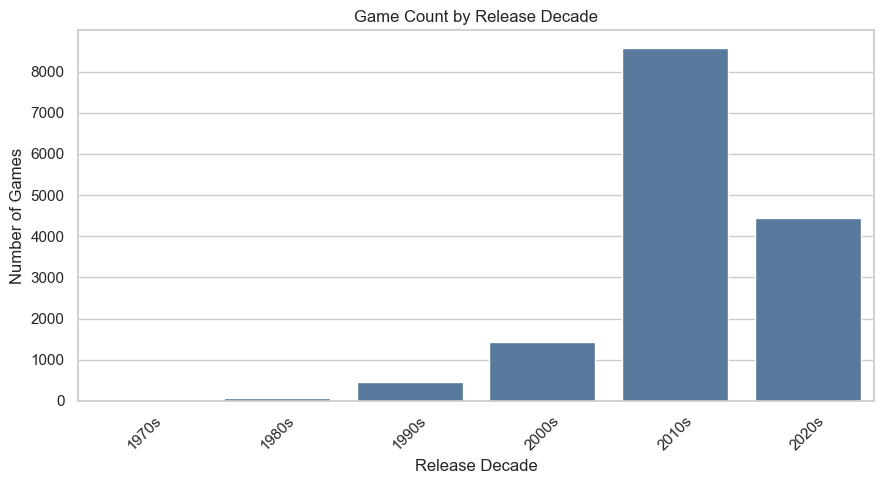

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/01_game_count_by_release_decade.png


In [8]:
if "release_decade" in df_features.columns:
    decade_counts = df_features["release_decade"].dropna().value_counts().sort_index()
    if not decade_counts.empty:
        plt.figure(figsize=(9, 5))
        sns.barplot(x=decade_counts.index, y=decade_counts.values, color="#4C78A8")
        plt.title("Game Count by Release Decade")
        plt.xlabel("Release Decade")
        plt.ylabel("Number of Games")
        plt.xticks(rotation=45)
        save_current_figure("01_game_count_by_release_decade.png")
    else:
        skip_plot("release_decade has no valid values")
else:
    skip_plot("release_decade column is missing")

这张柱状图用于观察数据集中的游戏是否集中在某些年代，例如 2010s 或 2020s。它可以帮助我们快速了解数据集的时间分布特点。

### 7.2 每年游戏发行数量变化

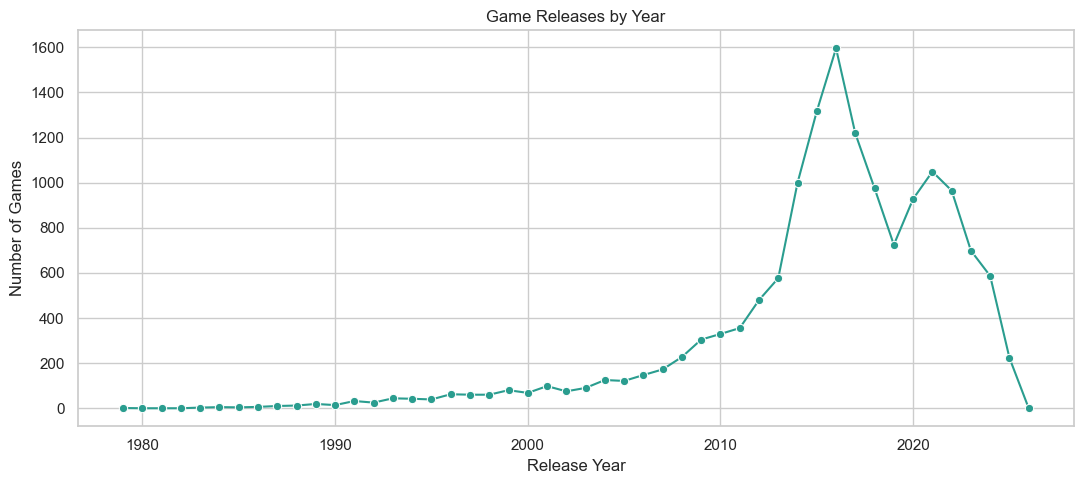

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/02_game_releases_by_year.png


In [9]:
if "release_year_num" in df_features.columns:
    year_counts = df_features["release_year_num"].dropna().astype(int).value_counts().sort_index()
    if not year_counts.empty:
        plt.figure(figsize=(11, 5))
        sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="#2A9D8F")
        plt.title("Game Releases by Year")
        plt.xlabel("Release Year")
        plt.ylabel("Number of Games")
        save_current_figure("02_game_releases_by_year.png")
    else:
        skip_plot("release_year_num has no valid values")
else:
    skip_plot("release_year_num column is missing")

年度折线图比年代柱状图更细，可以观察游戏发行数量是否在某些年份明显增加或减少，也可以检查数据集中是否存在年份覆盖不均衡的问题。

### 7.3 用户评分分布

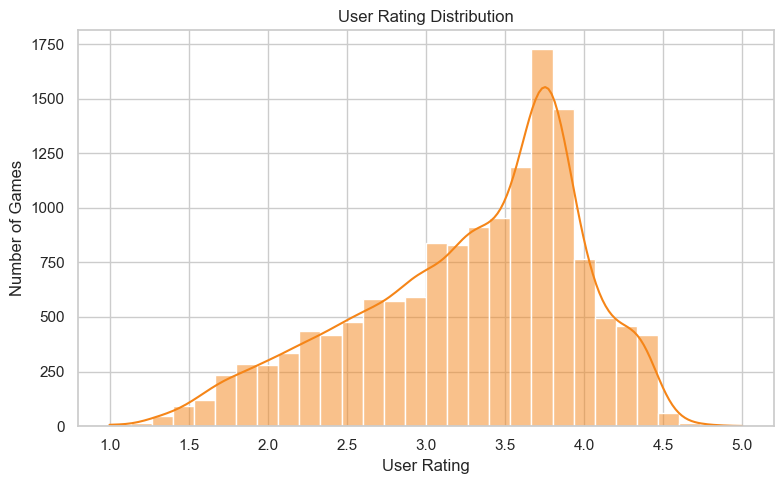

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/03_user_rating_distribution.png


In [10]:
ratings = numeric_series(df_features, "user_rating").dropna()
if not ratings.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(ratings, bins=30, kde=True, color="#F58518")
    plt.title("User Rating Distribution")
    plt.xlabel("User Rating")
    plt.ylabel("Number of Games")
    save_current_figure("03_user_rating_distribution.png")
else:
    skip_plot("user_rating column is missing or empty")

这张分布图用于观察 `user_rating` 的整体分布情况，例如评分是否集中在较高区间、是否存在明显偏态，以及低分或高分游戏的大致比例。

### 7.4 Metacritic 评分分布

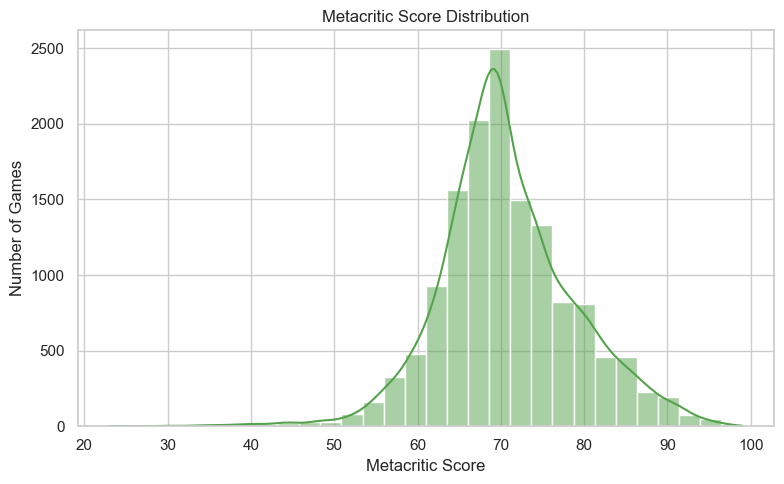

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/04_metacritic_distribution.png


In [11]:
metacritic_scores = numeric_series(df_features, "metacritic").dropna()
if not metacritic_scores.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(metacritic_scores, bins=30, kde=True, color="#54A24B")
    plt.title("Metacritic Score Distribution")
    plt.xlabel("Metacritic Score")
    plt.ylabel("Number of Games")
    save_current_figure("04_metacritic_distribution.png")
else:
    skip_plot("metacritic column is missing or empty")

Metacritic 评分可以理解为偏专业媒体评价的指标。它的分布可以与用户评分进行对照，帮助我们初步观察两类评分是否有不同特点。

### 7.5 数量最多的 10 个游戏类型

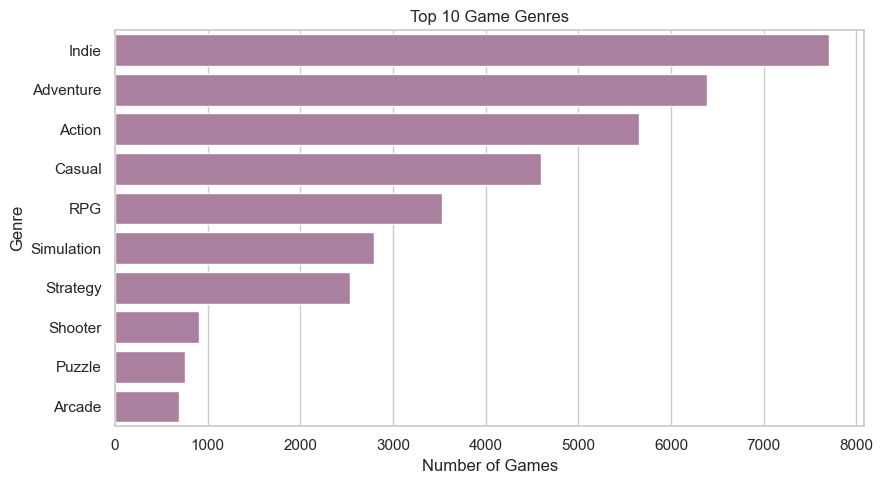

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/05_top_10_game_genres.png


In [12]:
if "all_genres_list" in df_features.columns:
    genre_counts = df_features["all_genres_list"].explode().dropna().value_counts().head(10)
    if not genre_counts.empty:
        plt.figure(figsize=(9, 5))
        sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#B279A2")
        plt.title("Top 10 Game Genres")
        plt.xlabel("Number of Games")
        plt.ylabel("Genre")
        save_current_figure("05_top_10_game_genres.png")
    else:
        skip_plot("all_genres_list has no valid values")
else:
    skip_plot("all_genres_list column is missing")

这张图统计的是 `all_genres` 中出现频率最高的游戏类型。由于一款游戏可以同时属于多个类型，所以这里统计的是类型标签出现次数，而不是互斥分类数量。

### 7.6 单平台游戏与多平台游戏的平均用户评分对比

/var/folders/yl/dc74thx936v5t2s24kmtx53m0000gn/T/ipykernel_63222/2742750592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_summary, x="platform_type", y="user_rating", palette=["#E45756", "#4C78A8"])


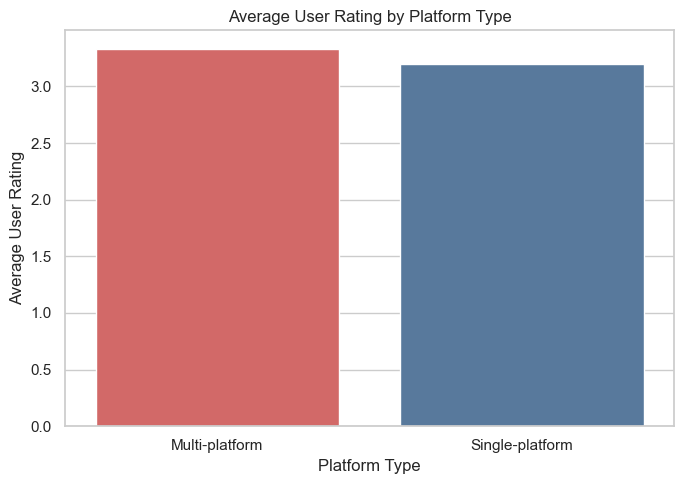

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/06_average_rating_by_platform_type.png


,platform_type,user_rating
0,Multi-platform,3.328
1,Single-platform,3.193


In [13]:
if {"platform_count_check", "user_rating"}.issubset(df_features.columns):
    rating_compare = pd.DataFrame({
        "platform_type": np.where(df_features["platform_count_check"] > 1, "Multi-platform", "Single-platform"),
        "user_rating": numeric_series(df_features, "user_rating"),
    }).dropna()
    if not rating_compare.empty:
        rating_summary = rating_compare.groupby("platform_type", as_index=False)["user_rating"].mean()
        plt.figure(figsize=(7, 5))
        sns.barplot(data=rating_summary, x="platform_type", y="user_rating", palette=["#E45756", "#4C78A8"])
        plt.title("Average User Rating by Platform Type")
        plt.xlabel("Platform Type")
        plt.ylabel("Average User Rating")
        save_current_figure("06_average_rating_by_platform_type.png")
        display(rating_summary.round(3))
    else:
        skip_plot("platform_count_check or user_rating has no valid values")
else:
    skip_plot("platform_count_check or user_rating column is missing")

这张图用于初步比较单平台游戏和多平台游戏的平均用户评分是否存在差异。这里的结果只是描述性统计，不能直接说明平台数量会导致评分变化。

### 7.7 平均游玩时长与用户评分的关系

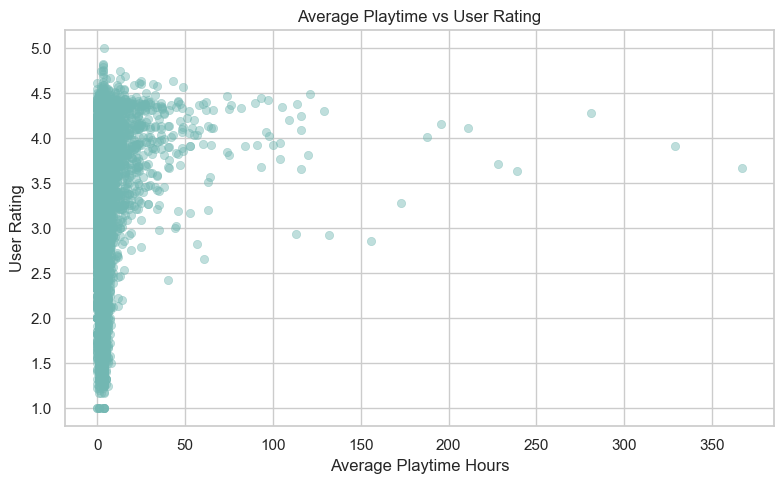

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/07_playtime_vs_user_rating.png


In [14]:
if {"avg_playtime_hours", "user_rating"}.issubset(df_features.columns):
    playtime_rating = pd.DataFrame({
        "avg_playtime_hours": numeric_series(df_features, "avg_playtime_hours"),
        "user_rating": numeric_series(df_features, "user_rating"),
    }).dropna()
    if not playtime_rating.empty:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=playtime_rating, x="avg_playtime_hours", y="user_rating", alpha=0.45, color="#72B7B2", edgecolor=None)
        plt.title("Average Playtime vs User Rating")
        plt.xlabel("Average Playtime Hours")
        plt.ylabel("User Rating")
        save_current_figure("07_playtime_vs_user_rating.png")
    else:
        skip_plot("avg_playtime_hours or user_rating has no valid values")
else:
    skip_plot("avg_playtime_hours or user_rating column is missing")

这张散点图用于观察平均游玩时长和用户评分之间是否存在直观关系，例如游玩时间更长的游戏是否更容易获得较高评分。

### 7.8 热度分数与参与度分数的关系

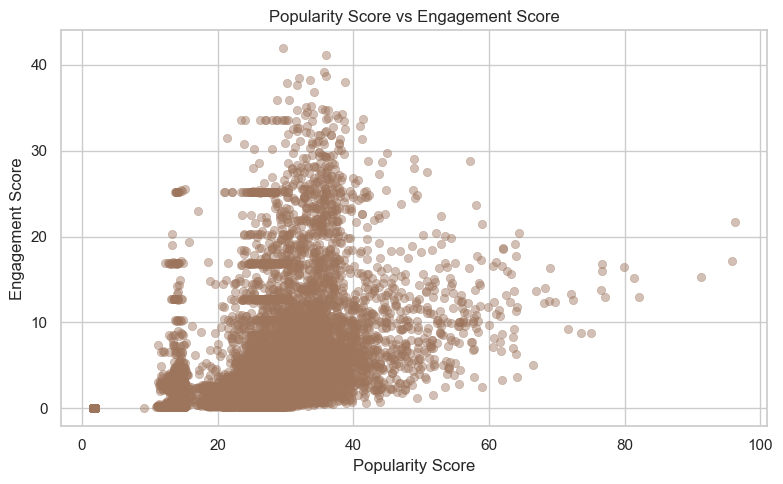

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/08_popularity_vs_engagement.png


In [15]:
if {"popularity_score", "engagement_score"}.issubset(df_features.columns):
    popularity_engagement = pd.DataFrame({
        "popularity_score": numeric_series(df_features, "popularity_score"),
        "engagement_score": numeric_series(df_features, "engagement_score"),
    }).dropna()
    if not popularity_engagement.empty:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=popularity_engagement, x="popularity_score", y="engagement_score", alpha=0.45, color="#9D755D", edgecolor=None)
        plt.title("Popularity Score vs Engagement Score")
        plt.xlabel("Popularity Score")
        plt.ylabel("Engagement Score")
        save_current_figure("08_popularity_vs_engagement.png")
    else:
        skip_plot("popularity_score or engagement_score has no valid values")
else:
    skip_plot("popularity_score or engagement_score column is missing")

这张散点图用于观察 `popularity_score` 和 `engagement_score` 之间是否存在正相关趋势。如果点大致从左下到右上分布，说明热度较高的游戏通常也有较高参与度。

## 8. 初步观察结论

根据当前 Notebook 的运行结果，可以得到以下非常初步的数据观察：

- 数据集规模：数据集包含 15,000 款游戏和 43 个字段，规模适合作为课程项目进行探索性数据分析。
- 发行年份分布：游戏发行时间明显集中在 2010s 和 2020s。其中 2010s 有 8,571 款游戏，2020s 有 4,453 款游戏，早期年代的数据量相对较少。
- 游戏类型分布：出现次数最多的类型标签包括 Indie、Adventure、Action、Casual 和 RPG。由于 `all_genres` 是多标签字段，这里的统计表示类型标签频次，而不是互斥类别数量。
- 评分分布：`user_rating` 有 14,613 条非缺失记录，平均值约为 3.27，中位数约为 3.43，评分范围是 1 到 5。`metacritic` 有 14,114 条非缺失记录，平均值约为 70.72，中位数为 70.00，评分范围是 23 到 99。
- 平台差异：在当前数据中，多平台游戏的平均用户评分约为 3.33，单平台游戏约为 3.19，多平台游戏略高。但这只是初步描述，不能解释因果关系。
- 热度与参与度：`popularity_score` 和 `engagement_score` 的相关系数约为 0.44，散点图上可以看到中等程度的正相关趋势。

以上结论只是初步 EDA 观察，不能直接作为因果判断或预测模型结果。后续如果要写项目报告，可以在这些观察基础上进一步补充图表截图和解释。